In [2]:
import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.utils.data import DataLoader, TensorDataset, Subset

from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

/home/qfu1/.local/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-04-01 19:47:58.841039: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 19:47:58.858931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743562078.879346 2931062 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0

In [3]:
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/token_to_number_combined.json", "r") as f:
    token_to_number_combined = json.load(f)
with open("/home/qfu1/ML_crystring/ML_crystring/CleanData/number_to_token_combined.json", "r") as f:
    number_to_token_combined = json.load(f)

In [4]:
df = pd.read_json("/home/qfu1/ML_crystring/ML_crystring/CleanData/CleanData(Tokenized).json", orient="records")
df["stable"] = (df["energy_above_hull"] < 0.1).astype(int)
df.head()

,string,band_gap,energy_above_hull,tokens,tokenized,stable
0,P 4bar n 2 Tb 4f 0.355 0.000 0.000,0.0,0.0,"[START, P, 4bar, n, 2, Tb, 4f, 3, 5, 5, 0, 0, ...","[13, 15, 101, 81, 47, 107, 58, 2, 8, 8, 1, 1, ...",1
1,P 6bar 1 1 Eu 2g 0.000 0.000 0.545 C 2g 0.000 ...,0.0,0.0,"[START, P, 6bar, 1, 1, Eu, 2g, 0, 0, 0, 0, 0, ...","[13, 15, 89, 17, 17, 145, 152, 1, 1, 1, 1, 1, ...",1
2,I 4bar c 2 Tl 4a 0.000 0.000 0.000 Cl 8f 0.000...,0.0,0.0,"[START, I, 4bar, c, 2, Tl, 4a, 0, 0, 0, 0, 0, ...","[13, 34, 101, 24, 47, 122, 27, 1, 1, 1, 1, 1, ...",1
3,P m c 21 Kr 4c 0.595 0.217 0.468 Tb 2a 0.000 0...,0.0,0.0,"[START, P, m, c, 21, Kr, 4c, 5, 9, 5, 2, 1, 7,...","[13, 15, 11, 24, 104, 277, 33, 8, 10, 8, 6, 3,...",1
4,P 3bar 1 c Co 2c 0.000 0.000 0.000,0.0,0.0,"[START, P, 3bar, 1, c, Co, 2c, 0, 0, 0, 0, 0, ...","[13, 15, 20, 17, 24, 72, 52, 1, 1, 1, 1, 1, 1,...",1


In [5]:
max_sequence_len = max([len(seq) for seq in df['tokenized']])
X = np.array(pad_sequences(df['tokenized'], maxlen=max_sequence_len, padding="pre"))
y = np.array(df["stable"]).reshape(-1,1)

# scaler = StandardScaler()
# y = scaler.fit_transform(y)

test_X = torch.tensor(X[:30], dtype=torch.long)
test_y = torch.tensor(y[:30], dtype=torch.float)

remaining_X = torch.tensor(X[30:], dtype=torch.long)
remaining_Y = torch.tensor(y[30:], dtype=torch.float)

print(test_X.shape, remaining_X.shape)
print(test_y.shape, remaining_Y.shape)

torch.Size([30, 639]) torch.Size([19059, 639])
torch.Size([30, 1]) torch.Size([19059, 1])


In [32]:
vocab_size = len(token_to_number_combined)+1
emb_dim = 16
hidden_size = 32
batch_size=512

In [33]:
X_trainval, X_test, y_trainval, y_test = train_test_split(remaining_X, remaining_Y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [34]:
class LSTMModel_C_EAH(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers=3):
        super(LSTMModel_C_EAH, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        self.lstm_layer = nn.LSTM(input_size=emb_dim, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 256),  
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # torch.Size([batch_size, max_sequence_len])
        embedding = self.embedding_layer(x)
        rnn_output, (hidden_state, cell_state) = self.lstm_layer(embedding)
        last_output = rnn_output[:, -1, :]
        # torch.Size([batch_size, hidden_size])
        final_output = torch.sigmoid(self.fc(last_output))
        # torch.Size([batch_size, 1])
        return final_output

In [35]:
def trian(train_loader, val_loader, model, criterion, optimizer, epochs, mute=False):
    TrainLoss = []
    ValLoss = []
    model.to(device)
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()                
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
    
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                val_loss += loss.item()

        train_loss = train_loss/len(train_loader)
        val_loss = val_loss/len(val_loader)
        
        TrainLoss.append(train_loss)
        ValLoss.append(val_loss)
        
        if not mute:
            if (epoch + 1) % 10 == 0:
                end_time = time.time()
                training_time = end_time - start_time
                print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {loss:.4f}, Time: {training_time:.2f}')
            
    return model, TrainLoss, ValLoss

In [36]:
lr=1e-3
wd=5e-5
epochs = 300
num_layers = 3

model = LSTMModel_C_EAH(vocab_size=vocab_size, emb_dim=emb_dim, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
model, TrainLoss, ValLoss = trian(train_loader, val_loader, model, criterion, optimizer, epochs)

Epoch [10/300] - Train Loss: 0.6467, Val Loss: 0.6623, Time: 15.33
Epoch [20/300] - Train Loss: 0.5527, Val Loss: 0.5110, Time: 30.53
Epoch [30/300] - Train Loss: 0.5111, Val Loss: 0.5031, Time: 45.56
Epoch [40/300] - Train Loss: 0.5230, Val Loss: 0.5044, Time: 60.60
Epoch [50/300] - Train Loss: 0.4768, Val Loss: 0.4084, Time: 75.68
Epoch [60/300] - Train Loss: 0.4584, Val Loss: 0.4426, Time: 90.74
Epoch [70/300] - Train Loss: 0.4473, Val Loss: 0.4881, Time: 106.17
Epoch [80/300] - Train Loss: 0.4310, Val Loss: 0.4353, Time: 121.22
Epoch [90/300] - Train Loss: 0.4208, Val Loss: 0.4236, Time: 136.28
Epoch [100/300] - Train Loss: 0.4090, Val Loss: 0.3378, Time: 151.29
Epoch [110/300] - Train Loss: 0.3876, Val Loss: 0.4313, Time: 166.44
Epoch [120/300] - Train Loss: 0.3782, Val Loss: 0.3570, Time: 181.57
Epoch [130/300] - Train Loss: 0.3591, Val Loss: 0.3787, Time: 197.07
Epoch [140/300] - Train Loss: 0.3395, Val Loss: 0.3418, Time: 212.33
Epoch [150/300] - Train Loss: 0.4303, Val Loss: 0

In [37]:
torch.save(model, f'/home/qfu1/TrainedModels/LstmToEnergyAboveHull_Classification_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth')
model = torch.load(f'/home/qfu1/TrainedModels/LstmToEnergyAboveHull_Classification_lr{lr}_wd{wd}_ep{epochs}_nl{num_layers}_bc{batch_size}.pth', weights_only=False)

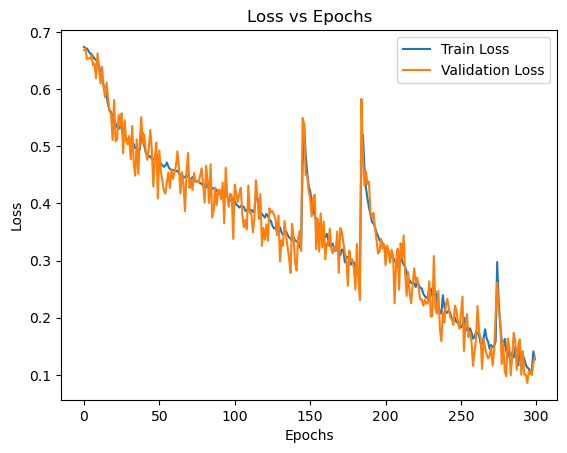

In [38]:
plt.plot(TrainLoss, label='Train Loss')
plt.plot(ValLoss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
def cm_plot(y_true, all_predictions):
    binary_predictions = (all_predictions >= 0.5).int()
    conf_matrix = confusion_matrix(y_true, binary_predictions)
    print("\nClassification Report:")
    target_names = ["Non-Stable", "Stable"]
    print(classification_report(y_true, binary_predictions, target_names=target_names))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
    disp.plot(cmap="Blues", values_format="d")
    plt.show()

In [40]:
all_predictions

tensor([[0.9467],
        [0.0027],
        [0.9921],
        ...,
        [0.9851],
        [0.9973],
        [0.0023]])

Training score

Classification Report:
              precision    recall  f1-score   support

  Non-Stable       0.95      0.92      0.94      4816
      Stable       0.95      0.97      0.96      7381

    accuracy                           0.95     12197
   macro avg       0.95      0.95      0.95     12197
weighted avg       0.95      0.95      0.95     12197



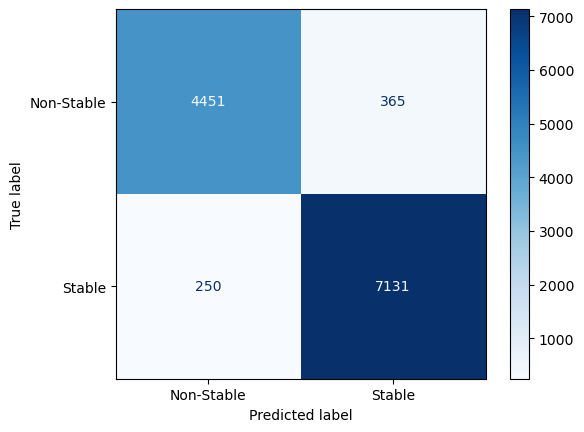

In [41]:
model.eval()
with torch.no_grad():
    X_train = X_train.to(device)
    all_predictions = model(X_train).cpu()

print("Training score")
cm_plot(y_train, all_predictions)

Testing score

Classification Report:
              precision    recall  f1-score   support

  Non-Stable       0.65      0.67      0.66      1480
      Stable       0.79      0.77      0.78      2332

    accuracy                           0.73      3812
   macro avg       0.72      0.72      0.72      3812
weighted avg       0.73      0.73      0.73      3812



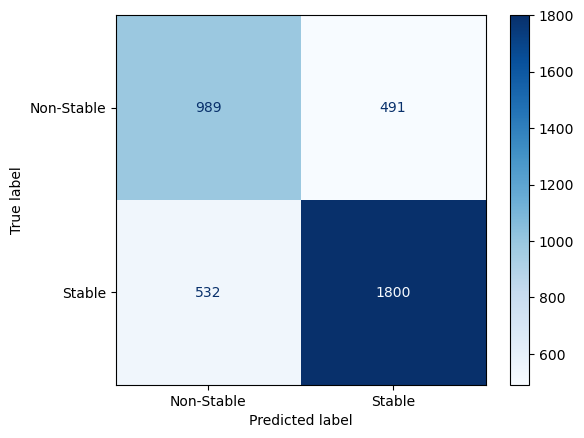

In [42]:
model.eval()
with torch.no_grad():
    X_test = X_test.to(device)
    all_predictions = model(X_test).cpu()
    
print("Testing score")
cm_plot(y_test, all_predictions)